# Polynomial Regression — When the Relationship Isn't a Straight Line

## The Problem with Straight Lines

Linear regression assumes the world is linear.
But most real-world relationships have **curves**:

| Relationship | Why it's curved |
|---|---|
| Car horsepower vs fuel efficiency | More power = much worse MPG, not linearly |
| Drug dose vs effect | Low doses do little, then effect grows, then plateaus |
| House size vs price | Small houses are cheap, large ones are expensive — but not proportionally |
| Temperature vs energy usage | Hot and cold both increase usage, neutral is the middle |

When you force a straight line on curved data, we get **systematic errors** — the model is wrong in a predictable, fixable way.

---

## The Key Insight — We Don't Change the Algorithm

Polynomial regression isn't a new algorithm.
It's **linear regression with transformed features**.

We take our original feature `x` and create new features: `x²`, `x³`, etc.
Then we feed all of them into plain linear regression.

```
Input:         x = [2, 3, 4]
After degree 3: [[2, 4,  8 ],
                 [3, 9,  27],
                 [4, 16, 64]]
                  x   x²  x³
```

The model then fits:  `ŷ = w₁x + w₂x² + w₃x³ + b`

Linear in the **weights** (w₁, w₂, w₃) — that's all linear regression needs.

---

## What We'll Cover

| Section | Topic |
|---------|-------|
| 1 | Seeing the problem — linear on non-linear data |
| 2 | How polynomial features are built |
| 3 | Fitting polynomial models — the right way |
| 4 | The danger: high-degree = overfitting |
| 5 | The fix: regularization + polynomial features |
| 6 | Choosing the right degree |
| 7 | Multiple features — what happens in 2D+ |
| 8 | Real Dataset — Auto MPG (Kaggle) |

---

## Dataset

**Auto MPG Dataset** — predict fuel efficiency from engine specs.
This dataset has a famously non-linear relationship between horsepower and MPG.

Download from: https://www.kaggle.com/datasets/uciml/autompg-dataset
Save `auto-mpg.csv` to `./datasets/` folder.

```python
df = pd.read_csv('/datasets/auto-mpg.csv')
```


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import  StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

print("All libraries loaded ✓")


All libraries loaded ✓


---
## Section 1 — Seeing the Problem

Before we solve anything, let's *feel* why linear regression fails on curved data.

We'll create a simple dataset where the true relationship is a curve,  
then watch linear regression struggle with it.

### Reading the Residual Plot

The residual plot is your diagnostic tool.  
**Residual = Actual - Predicted** — how wrong was the model for each point?

```
If residuals look random → model is correct
If residuals show a pattern → model is systematically wrong
```

A curve in the residual plot = the model is missing non-linearity.


Linear Regression R² — Train: 0.0946  |  Test: 0.0351
R² isn't terrible, but we're leaving a lot on the table.
The residual plot will show us exactly what we're missing.


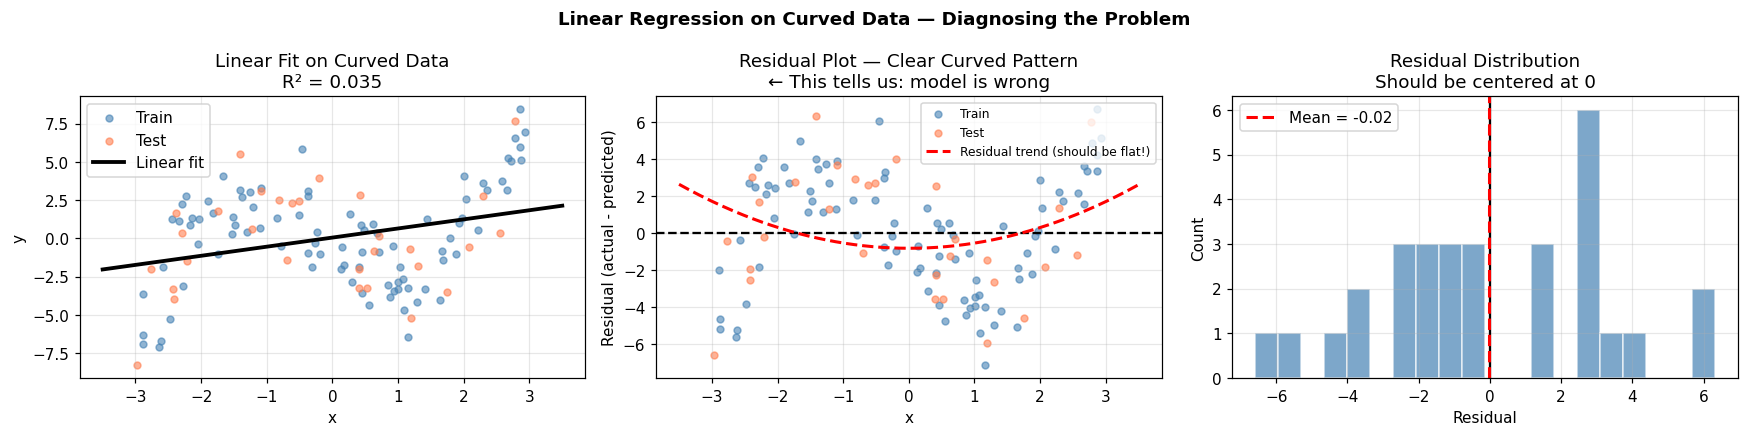


What the residual plot is telling us:
  Left side (x < 0): residuals mostly positive → model under-predicts
  Middle (x ≈ 0):    residuals near zero       → model is OK here
  Right side (x > 0):residuals mostly positive → model under-predicts again

Pattern = the model is systematically wrong = add polynomial features!


In [55]:
# from numpy.polynomial.polynomial import polyfit as npfit

# ── Create clearly non-linear data ───────────────────────────────────────────
np.random.seed(0)
n = 120

x = np.sort(np.random.uniform(-3, 3, n))

# True relationship: cubic (we'd see this with temperature vs energy, horsepower vs mpg, etc.)
y_true = 0.6 * x**3 - 2.5 * x + np.random.normal(0, 2, n)

X = x.reshape(-1, 1)   # sklearn expects 2D input

X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.25, random_state=42)

# ── Fit a straight line ───────────────────────────────────────────────────────
lin = LinearRegression()
lin.fit(X_train, y_train)

x_plot = np.linspace(-3.5, 3.5, 300).reshape(-1, 1)
y_lin  = lin.predict(x_plot)

resids_train = y_train - lin.predict(X_train)
resids_test  = y_test  - lin.predict(X_test)

r2_tr = r2_score(y_train, lin.predict(X_train))
r2_te = r2_score(y_test,  lin.predict(X_test))

print(f"Linear Regression R² — Train: {r2_tr:.4f}  |  Test: {r2_te:.4f}")
print("R² isn't terrible, but we're leaving a lot on the table.")
print("The residual plot will show us exactly what we're missing.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Data + linear fit
axes[0].scatter(X_train, y_train, s=20, alpha=0.6, color='steelblue', label='Train')
axes[0].scatter(X_test,  y_test,  s=20, alpha=0.6, color='coral',     label='Test')
axes[0].plot(x_plot, y_lin, 'k-', lw=2.5, label='Linear fit')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Linear Fit on Curved Data\nR² = {r2_te:.3f}')
axes[0].legend()

# Residuals vs x — should look random if model is right
axes[1].scatter(X_train, resids_train, s=20, alpha=0.6, color='steelblue', label='Train')
axes[1].scatter(X_test,  resids_test,  s=20, alpha=0.6, color='coral',     label='Test')
axes[1].axhline(0, color='k', lw=1.5, ls='--')
# Add a smoothed trend to highlight the pattern

trend_coef = np.polyfit(X_train.ravel(), resids_train, 2)
trend_line  = np.polyval(trend_coef, x_plot.ravel())
axes[1].plot(x_plot, trend_line, 'red', lw=2, ls='--', label='Residual trend (should be flat!)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residual Plot — Clear Curved Pattern\n← This tells us: model is wrong')
axes[1].legend(fontsize=8)

# Residual histogram
axes[2].hist(resids_test, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
axes[2].axvline(0, color='k', lw=1.5)
axes[2].axvline(resids_test.mean(), color='red', lw=2, ls='--',
                label=f'Mean = {resids_test.mean():.2f}')
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution\nShould be centered at 0')
axes[2].legend()

plt.suptitle('Linear Regression on Curved Data — Diagnosing the Problem', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("What the residual plot is telling us:")
print("  Left side (x < 0): residuals mostly positive → model under-predicts")
print("  Middle (x ≈ 0):    residuals near zero       → model is OK here")
print("  Right side (x > 0):residuals mostly positive → model under-predicts again")
print()
print("Pattern = the model is systematically wrong = add polynomial features!")


---
## Section 2 — How Polynomial Features Are Built

### What `PolynomialFeatures` Does

It takes original features and creates all polynomial combinations up to a given degree.

For a **single feature** `x` with `degree=3`:
```
Original: [x]
Output:   [1, x, x², x³]
           ↑ bias term (the intercept)
```

For **two features** `[a, b]` with `degree=2`:
```
Original: [a, b]
Output:   [1, a, b, a², a×b, b²]
```

The feature count grows fast with degree:
- 1 feature, degree 2 → 3 features
- 1 feature, degree 5 → 6 features
- 5 features, degree 2 → 21 features
- 5 features, degree 3 → 56 features

This is why high degrees + many features can explode into thousands of columns.


In [56]:
from sklearn.preprocessing import PolynomialFeatures

# ── Show what PolynomialFeatures actually creates ─────────────────────────────
print("=" * 60)
print("  PolynomialFeatures: What gets created?")
print("=" * 60)

x_demo = np.array([[2.0]])   # single sample, single feature: x=2

for degree in [1, 2, 3, 4, 5]:
    pf   = PolynomialFeatures(degree=degree, include_bias=True)
    out  = pf.fit_transform(x_demo)
    names = pf.get_feature_names_out(['x'])
    print(f"  degree={degree}  → {len(names):2d} features: {list(names)}")
    print(f"           values: {out.ravel().tolist()}")
    print()

# ── Two features example ──────────────────────────────────────────────────────
print("=" * 60)
print("  Two features [a=2, b=3], degree=2")
print("=" * 60)
pf2   = PolynomialFeatures(degree=2, include_bias=True)
demo2 = np.array([[2.0, 3.0]])
out2  = pf2.fit_transform(demo2)
names2 = pf2.get_feature_names_out(['a', 'b'])
for name, val in zip(names2, out2.ravel()):
    print(f"  {name:>8}  =  {val:.1f}")

print()
print("=" * 60)
print("  Feature explosion: n_features vs n_output_features")
print("=" * 60)
print(f"  {'Features':>10}  {'Degree':>8}  {'Output columns':>16}")
print("  " + "-" * 40)
for n_feat in [1, 2, 5, 10]:
    for deg in [2, 3]:
        pf_test = PolynomialFeatures(degree=deg)
        dummy   = np.zeros((1, n_feat))
        n_out   = pf_test.fit_transform(dummy).shape[1]
        print(f"  {n_feat:>10}  {deg:>8}  {n_out:>16}")


  PolynomialFeatures: What gets created?
  degree=1  →  2 features: ['1', 'x']
           values: [1.0, 2.0]

  degree=2  →  3 features: ['1', 'x', 'x^2']
           values: [1.0, 2.0, 4.0]

  degree=3  →  4 features: ['1', 'x', 'x^2', 'x^3']
           values: [1.0, 2.0, 4.0, 8.0]

  degree=4  →  5 features: ['1', 'x', 'x^2', 'x^3', 'x^4']
           values: [1.0, 2.0, 4.0, 8.0, 16.0]

  degree=5  →  6 features: ['1', 'x', 'x^2', 'x^3', 'x^4', 'x^5']
           values: [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

  Two features [a=2, b=3], degree=2
         1  =  1.0
         a  =  2.0
         b  =  3.0
       a^2  =  4.0
       a b  =  6.0
       b^2  =  9.0

  Feature explosion: n_features vs n_output_features
    Features    Degree    Output columns
  ----------------------------------------
           1         2                 3
           1         3                 4
           2         2                 6
           2         3                10
           5         2                2

---
## Section 3 — Fitting Polynomial Models the Right Way

### The Pipeline

Always use a **Pipeline** that chains:
1. `PolynomialFeatures(degree=n)` — create the new features
2. `StandardScaler()` — scale them (x² and x³ have very different scales!)
3. `LinearRegression()` — fit a linear model on the expanded features

```python
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('model',  LinearRegression()),
])

pipe.fit(X_train, y_train)
pipe.predict(X_test)
```

### Why StandardScaler?

x=2, x²=4, x³=8, x⁴=16, x⁵=32 — the scales grow exponentially.  
Without scaling, the optimizer struggles.  
With scaling, every feature gets mean=0, std=1 — fair treatment.


  Polynomial Regression at Different Degrees
    Degree    Train R²     Test R²    # features
  ------------------------------------------------
         1      0.0946      0.0351             1
         2      0.1469     -0.0604             2
         3      0.6745      0.5985             3 ← sweet spot
         4      0.6830      0.5729             4
         6      0.6956      0.5620             6 ← OVERFIT
         9      0.7197      0.4925             9 ← OVERFIT


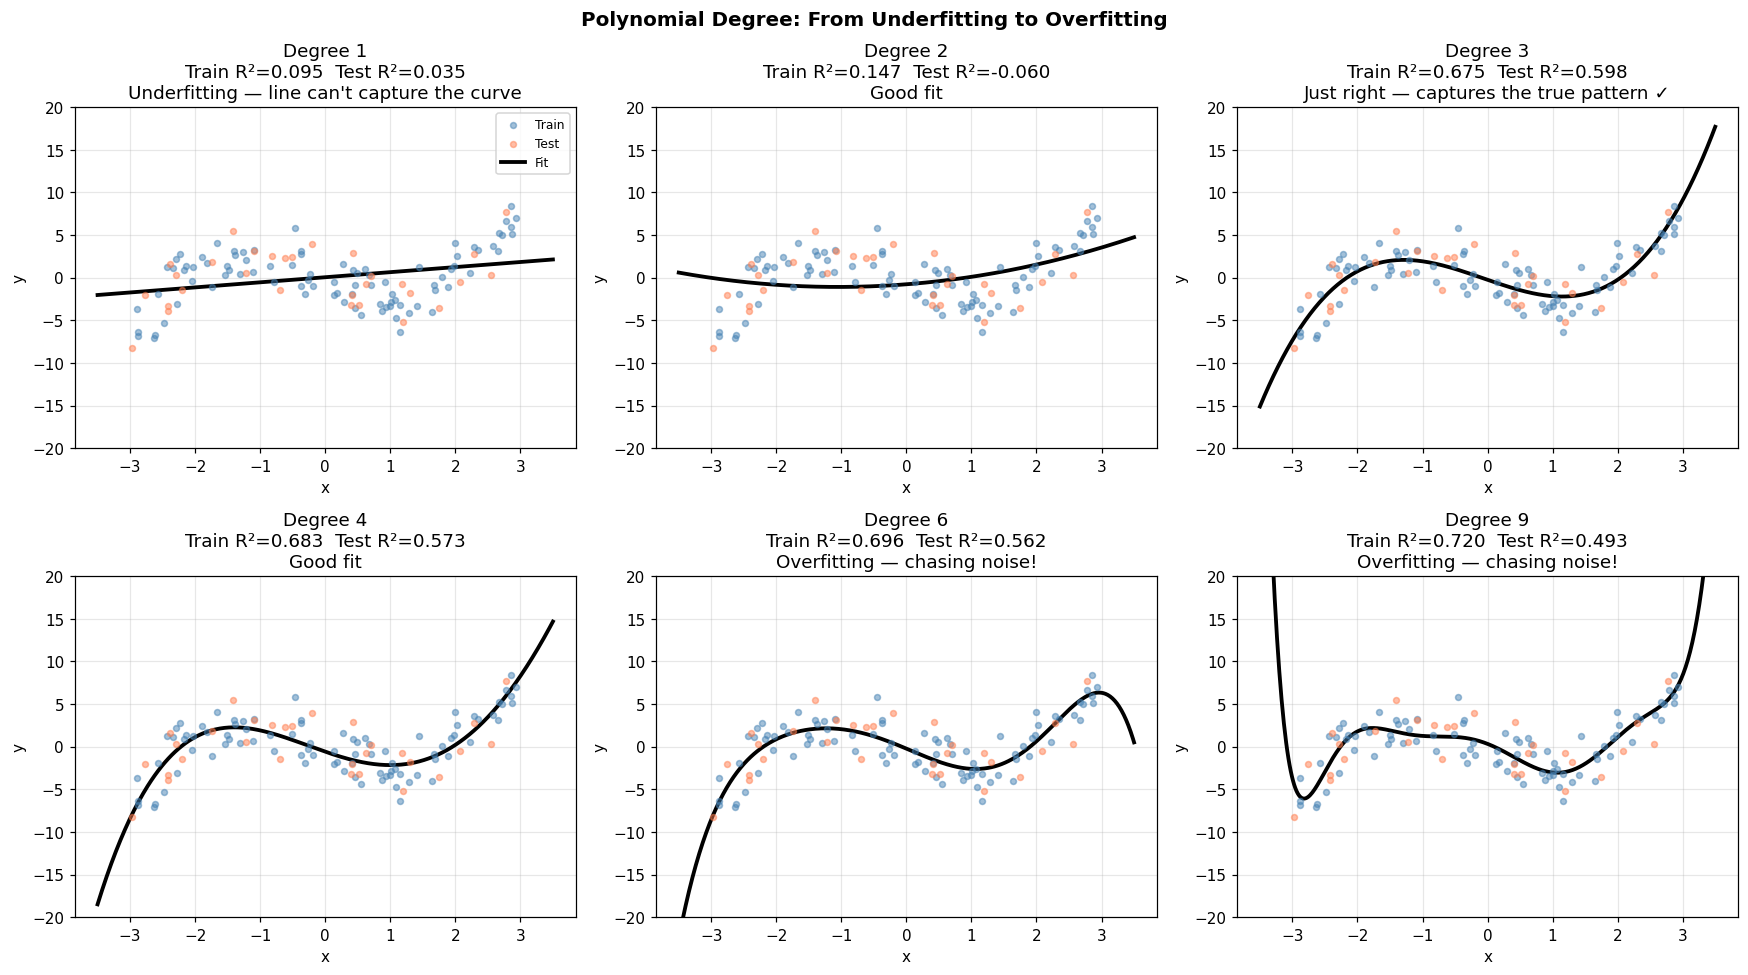

In [57]:
# ── Fit polynomial models at different degrees ─────────────────────────────────
degrees = [1, 2, 3, 4, 6, 9]

x_plot = np.linspace(-3.5, 3.5, 400).reshape(-1, 1)

print("=" * 55)
print("  Polynomial Regression at Different Degrees")
print("=" * 55)
print(f"  {'Degree':>8}  {'Train R²':>10}  {'Test R²':>10}  {'# features':>12}")
print("  " + "-" * 48)

poly_results = {}
for deg in degrees:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ])
    pipe.fit(X_train, y_train)

    r2_tr = r2_score(y_train, pipe.predict(X_train))
    r2_te = r2_score(y_test,  pipe.predict(X_test))
    n_feat = pipe.named_steps['poly'].n_output_features_

    poly_results[deg] = {'pipe': pipe, 'r2_tr': r2_tr, 'r2_te': r2_te, 'n_feat': n_feat}

    flag = " ← sweet spot" if deg == 3 else ""
    flag = " ← OVERFIT"  if deg >= 6 else flag
    print(f"  {deg:>8}  {r2_tr:>10.4f}  {r2_te:>10.4f}  {n_feat:>12}{flag}")

# ── Visualize each degree ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, deg in zip(axes.flat, degrees):
    pipe = poly_results[deg]['pipe']
    r2_tr = poly_results[deg]['r2_tr']
    r2_te = poly_results[deg]['r2_te']

    y_curve = pipe.predict(x_plot)

    ax.scatter(X_train, y_train, s=15, alpha=0.5, color='steelblue', label='Train', zorder=3)
    ax.scatter(X_test,  y_test,  s=15, alpha=0.5, color='coral',     label='Test',  zorder=3)
    ax.plot(x_plot, np.clip(y_curve, -25, 25), 'k-', lw=2.5, label='Fit')

    ax.set_ylim(-20, 20)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    if deg == 1:
        status = "Underfitting — line can't capture the curve"
    elif deg == 3:
        status = "Just right — captures the true pattern ✓"
    elif deg >= 6:
        status = "Overfitting — chasing noise!"
    else:
        status = "Good fit"

    ax.set_title(f'Degree {deg}\nTrain R²={r2_tr:.3f}  Test R²={r2_te:.3f}\n{status}')

    if deg == 1:
        ax.legend(fontsize=8)

plt.suptitle('Polynomial Degree: From Underfitting to Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 4 — The Danger: High Degree = Overfitting

Let's zoom in on what happens as degree increases.

### The Bias-Variance Curve

As we increase polynomial degree:
- **Bias decreases** — the model can fit more complex shapes
- **Variance increases** — the model becomes sensitive to small changes in data

There's a sweet spot where both are low enough.  
Beyond that, the model memorizes noise and performs badly on new data.

### What Overfitting Looks Like

A degree-15 polynomial will perfectly connect all training points —  
including the random noise. On test data, those wiggles are completely wrong.


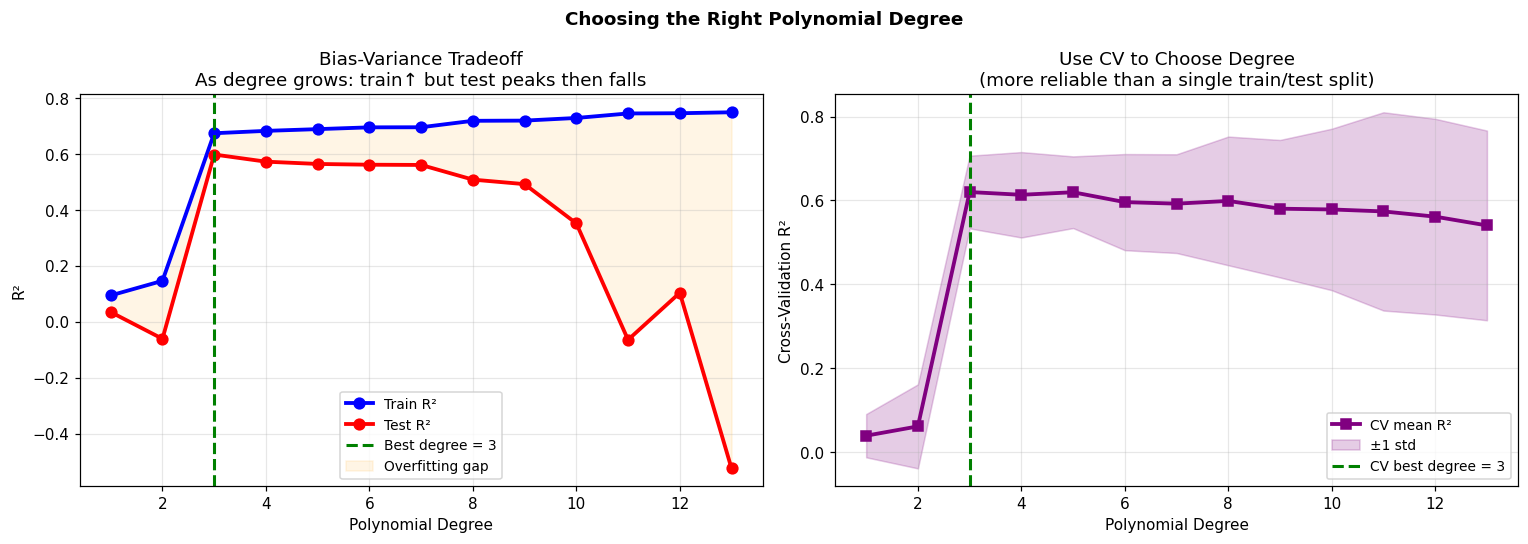

Best degree by test R²:        3
Best degree by cross-validation: 3

CV is preferred because it doesn't depend on a single lucky/unlucky test split.


In [58]:
# ── Bias-variance curve across degrees ───────────────────────────────────────
degree_range = range(1, 14)

train_r2s = []
test_r2s  = []
cv_means  = []
cv_stds   = []

for deg in degree_range:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ])
    pipe.fit(X_train, y_train)
    train_r2s.append(r2_score(y_train, pipe.predict(X_train)))
    test_r2s.append( r2_score(y_test,  pipe.predict(X_test)))

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

train_r2s = np.array(train_r2s)
test_r2s  = np.array(test_r2s)
cv_means  = np.array(cv_means)
cv_stds   = np.array(cv_stds)

best_degree_cv   = list(degree_range)[np.argmax(cv_means)]
best_degree_test = list(degree_range)[np.argmax(test_r2s)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bias-variance curve
axes[0].plot(degree_range, train_r2s, 'b-o', ms=7, lw=2.5, label='Train R²')
axes[0].plot(degree_range, test_r2s,  'r-o', ms=7, lw=2.5, label='Test R²')
axes[0].axvline(best_degree_test, color='green', ls='--', lw=2,
                label=f'Best degree = {best_degree_test}')
axes[0].fill_between(degree_range, train_r2s, test_r2s,
                      alpha=0.1, color='orange', label='Overfitting gap')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('R²')
axes[0].set_title('Bias-Variance Tradeoff\nAs degree grows: train↑ but test peaks then falls')
axes[0].legend(fontsize=9)

# Cross-validation curve (more reliable than single test split)
axes[1].plot(degree_range, cv_means, 'purple', lw=2.5, marker='s', ms=7, label='CV mean R²')
axes[1].fill_between(degree_range, cv_means - cv_stds, cv_means + cv_stds,
                      alpha=0.2, color='purple', label='±1 std')
axes[1].axvline(best_degree_cv, color='green', ls='--', lw=2,
                label=f'CV best degree = {best_degree_cv}')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Cross-Validation R²')
axes[1].set_title('Use CV to Choose Degree\n(more reliable than a single train/test split)')
axes[1].legend(fontsize=9)

plt.suptitle('Choosing the Right Polynomial Degree', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best degree by test R²:        {best_degree_test}")
print(f"Best degree by cross-validation: {best_degree_cv}")
print()
print("CV is preferred because it doesn't depend on a single lucky/unlucky test split.")


---
## Section 5 — The Fix: Regularization + Polynomial Features

Using a high-degree polynomial without regularization = disaster.  
But using a high-degree polynomial **with Ridge regularization** = controlled flexibility.

### Why This Works

Ridge penalizes large weights. High-degree polynomial terms that just fit noise  
require large weights. So Ridge suppresses them automatically.

We can use a **high degree** (flexible model) with a **high λ** (strong regularization)  
and get the best of both worlds:
- Enough flexibility to fit real curves
- Enough constraint to avoid overfitting

### The Standard Practice

Use `degree=3` or `degree=4` with `RidgeCV`.  
The CV automatically finds the λ that controls the flexibility.

```python
pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
])
```


  Degree-9 Polynomial — Effect of Ridge Regularization
         λ    Train R²     Test R²    Max |weight|
  --------------------------------------------------
         0      0.7197      0.4925            57.1 ← best
      0.01      0.7074      0.5526            18.5 ← best
       0.1      0.6946      0.5613             5.5 ← best
       1.0      0.6791      0.5583             3.5
      10.0      0.6001      0.4949             1.5
     100.0      0.4615      0.3585             0.5
    1000.0      0.2142      0.1517             0.1


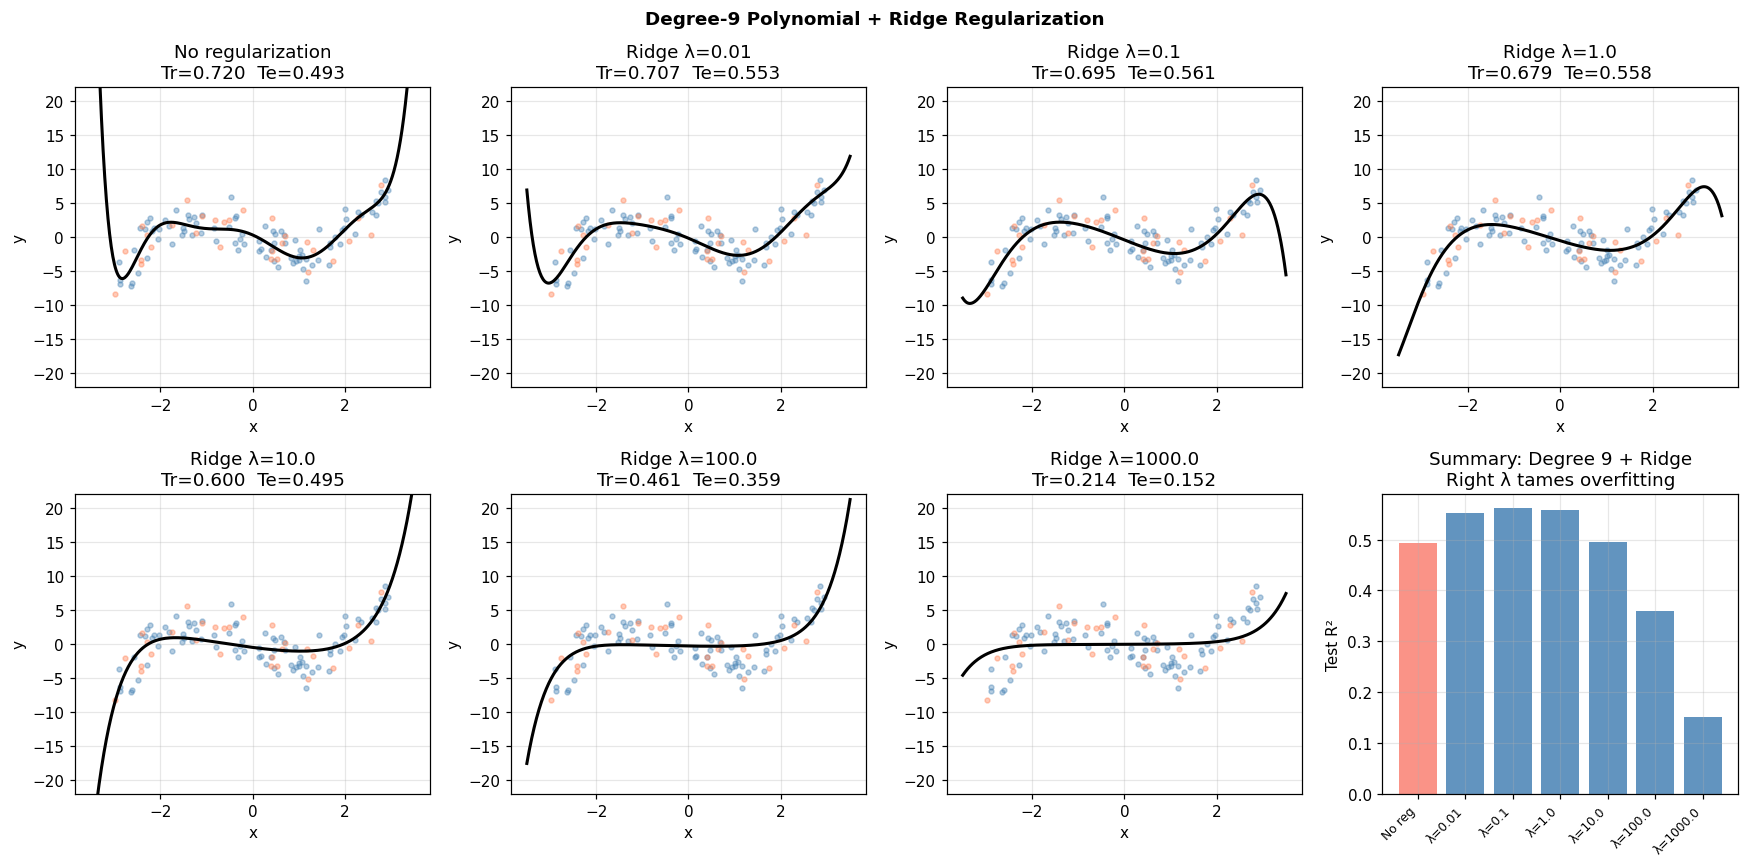

In [59]:
# ── High degree + Ridge: compare with and without regularization ───────────────
degree_high = 9   # intentionally high — would badly overfit without regularization

lambdas_demo = [0, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

print("=" * 65)
print(f"  Degree-{degree_high} Polynomial — Effect of Ridge Regularization")
print("=" * 65)
print(f"  {'λ':>8}  {'Train R²':>10}  {'Test R²':>10}  {'Max |weight|':>14}")
print("  " + "-" * 50)

reg_poly_results = []
for lam in lambdas_demo:
    if lam == 0:
        model = LinearRegression()
        label = "No reg"
    else:
        model = Ridge(alpha=lam)
        label = f"λ={lam}"

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=degree_high, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  model),
    ])
    pipe.fit(X_train, y_train)
    r2_tr = r2_score(y_train, pipe.predict(X_train))
    r2_te = r2_score(y_test,  pipe.predict(X_test))
    max_w = np.max(np.abs(pipe.named_steps['model'].coef_))
    reg_poly_results.append({'lam': lam, 'pipe': pipe, 'r2_tr': r2_tr, 'r2_te': r2_te, 'max_w': max_w})

    flag = " ← best" if r2_te == max(r['r2_te'] for r in reg_poly_results) else ""
    print(f"  {str(lam):>8}  {r2_tr:>10.4f}  {r2_te:>10.4f}  {max_w:>14.1f}{flag}")

# ── Visualize the effect ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

x_plot = np.linspace(-3.5, 3.5, 400).reshape(-1, 1)

for ax, res in zip(axes_flat[:len(lambdas_demo)], reg_poly_results):
    y_curve = res['pipe'].predict(x_plot)
    ax.scatter(X_train, y_train, s=10, alpha=0.4, color='steelblue')
    ax.scatter(X_test,  y_test,  s=10, alpha=0.4, color='coral')
    ax.plot(x_plot, np.clip(y_curve, -30, 30), 'k-', lw=2)
    ax.set_ylim(-22, 22)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    lam_label = "No regularization" if res['lam'] == 0 else f"Ridge λ={res['lam']}"
    ax.set_title(f'{lam_label}\nTr={res["r2_tr"]:.3f}  Te={res["r2_te"]:.3f}')

# Summary comparison in last panel
r2_te_all = [r['r2_te'] for r in reg_poly_results]
lam_labels = ['No reg'] + [f'λ={r["lam"]}' for r in reg_poly_results[1:]]
colors_bar = ['salmon'] + ['steelblue'] * (len(reg_poly_results) - 1)
axes_flat[7].bar(range(len(r2_te_all)), r2_te_all, color=colors_bar, alpha=0.85)
axes_flat[7].set_xticks(range(len(lam_labels)))
axes_flat[7].set_xticklabels(lam_labels, rotation=45, ha='right', fontsize=8)
axes_flat[7].set_ylabel('Test R²')
axes_flat[7].set_title(f'Summary: Degree {degree_high} + Ridge\nRight λ tames overfitting')

plt.suptitle(f'Degree-{degree_high} Polynomial + Ridge Regularization',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 6 — Choosing the Right Degree

### Decision Guide

```
Step 1: Start with degree=2
        → Good enough for many real-world curves

Step 2: Plot residuals
        → Still curved? Try degree=3 or degree=4

Step 3: Use cross-validation
        → Loop over degrees [1,2,3,4,5], pick the one with best CV score

Step 4: Add regularization
        → Use RidgeCV regardless — it helps even when degree is right

Step 5: If features > 3, keep degree=2
        → Feature explosion becomes unmanageable beyond degree=2 for many features
```

### The Grid Search Approach

When we're not sure about both degree AND λ, try all combinations:


  Grid Search: Best Degree + Lambda Combination
  Best degree:  3
  Best lambda:  0.3793
  Best CV R²:   0.6224
  Test R²:      0.5918


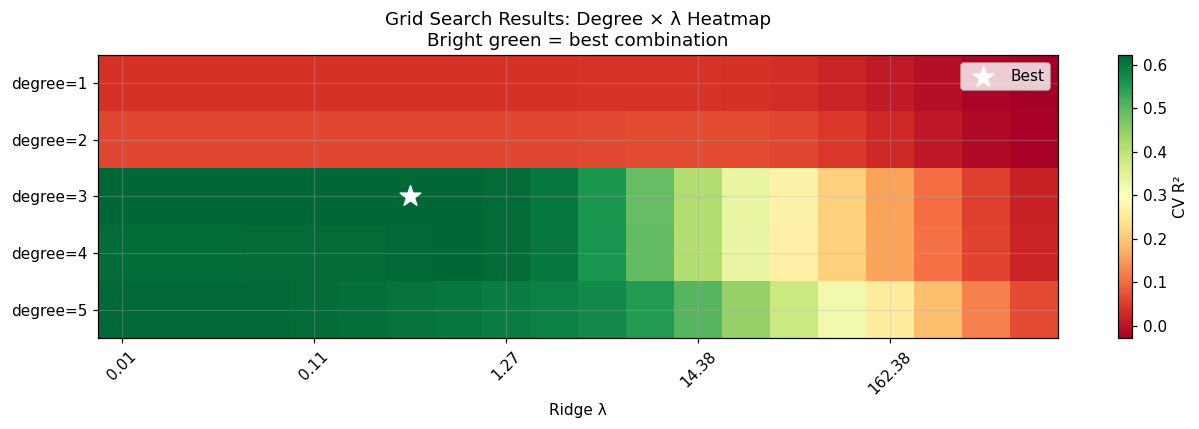

In [60]:
# ── Grid search over degree and lambda ────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

# Build a pipeline where degree is a hyperparameter
pipe_gs = Pipeline([
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge()),
])

# Define the grid
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5],
    'ridge__alpha': np.logspace(-2, 3, 20),
}

gs = GridSearchCV(pipe_gs, param_grid, cv=5, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)

print("=" * 55)
print("  Grid Search: Best Degree + Lambda Combination")
print("=" * 55)
print(f"  Best degree:  {gs.best_params_['poly__degree']}")
print(f"  Best lambda:  {gs.best_params_['ridge__alpha']:.4f}")
print(f"  Best CV R²:   {gs.best_score_:.4f}")
print(f"  Test R²:      {r2_score(y_test, gs.predict(X_test)):.4f}")

# ── Heatmap of results ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(gs.cv_results_)
degrees    = param_grid['poly__degree']
alphas     = param_grid['ridge__alpha']

# Reshape CV scores into a degree × alpha grid
scores = results_df['mean_test_score'].to_numpy()
scores_grid = scores.reshape(len(degrees), len(alphas))

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(scores_grid, aspect='auto', cmap='RdYlGn', vmin=scores_grid.min(), vmax=scores_grid.max())
plt.colorbar(im, ax=ax, label='CV R²')

ax.set_yticks(range(len(degrees)))
ax.set_yticklabels([f'degree={d}' for d in degrees])
ax.set_xticks(range(0, len(alphas), 4))
ax.set_xticklabels([f'{a:.2f}' for a in alphas[::4]], rotation=45)
ax.set_xlabel('Ridge λ')
ax.set_title('Grid Search Results: Degree × λ Heatmap\n'
            'Bright green = best combination')

# Mark the best
best_deg_idx = degrees.index(gs.best_params_['poly__degree'])
best_alpha_idx = np.argmin(np.abs(alphas - gs.best_params_['ridge__alpha']))
ax.scatter([best_alpha_idx], [best_deg_idx], color='white', s=200, marker='*',
          zorder=5, label='Best')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## Section 7 — Multiple Features: What Happens in 2D?

So far we've used a single feature. In practice, we have many.

With two features `[a, b]` and `degree=2`, `PolynomialFeatures` creates:
```
[1, a, b, a², a×b, b²]
```

The `a×b` term is called an **interaction term** — it captures how  
the effect of `a` changes depending on the value of `b`.

**Example:** House price  
- Size matters. Quality matters.  
- But a large AND high-quality house is worth much more than either alone.  
- That synergy is captured by `size × quality`.

### Feature Explosion Warning

With `n` features and `degree=d`, the output columns ≈ `n^d / d!`

| Features | Degree | Output columns |
|---|---|---|
| 10 | 2 | 66 |
| 10 | 3 | 286 |
| 50 | 2 | 1,326 |
| 50 | 3 | 23,426 |

**Practical rule:** If we have more than ~5 features, stick to degree=2.  
Or use Lasso/Ridge aggressively to zero out the useless interactions.


  Two Features: Linear vs Degree-2 Polynomial
  Linear (no interactions)
    Features created: 2
    Train R²: 0.0230  |  Test R²: -0.0208

  Degree 2 (with interactions)
    Features created: 5
    Train R²: 0.9605  |  Test R²: 0.9321



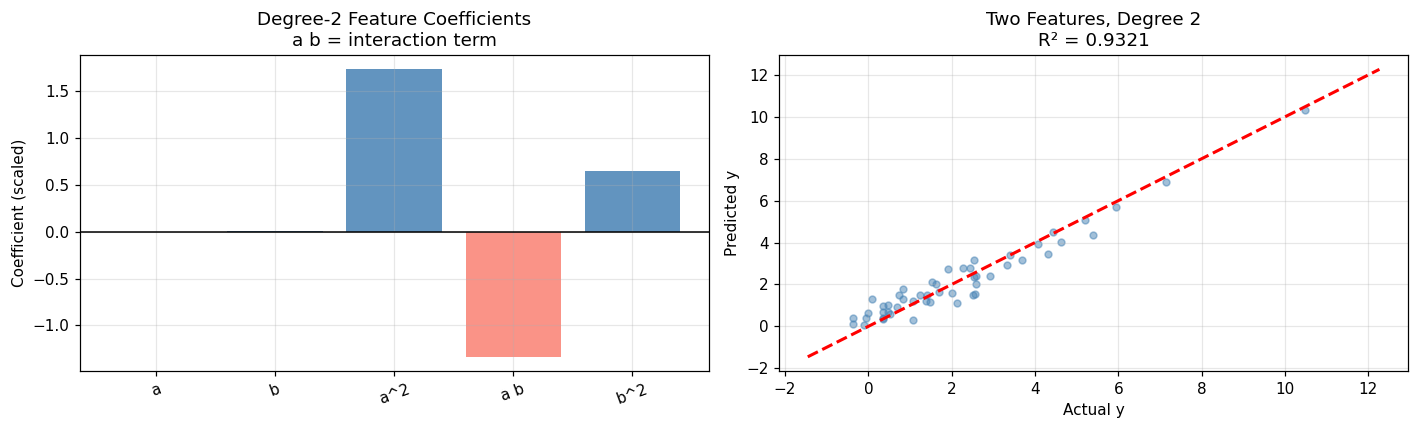

In [61]:
# ── Two feature polynomial regression visualization ────────────────────────────
np.random.seed(2)
n2 = 200

a = np.random.uniform(-2, 2, n2)
b = np.random.uniform(-2, 2, n2)

# True relationship has an interaction: a*b matters
y2 = 1.5*a**2 - a*b + 0.5*b**2 + np.random.normal(0, 0.5, n2)

X2 = np.column_stack([a, b])
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.25, random_state=42)

print("=" * 60)
print("  Two Features: Linear vs Degree-2 Polynomial")
print("=" * 60)

for deg, name in [(1, 'Linear (no interactions)'), (2, 'Degree 2 (with interactions)')]:
    pipe2 = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0)),
    ])
    pipe2.fit(X2_tr, y2_tr)
    r2_tr2 = r2_score(y2_tr, pipe2.predict(X2_tr))
    r2_te2 = r2_score(y2_te, pipe2.predict(X2_te))
    n_feat2 = pipe2.named_steps['poly'].n_output_features_
    print(f"  {name}")
    print(f"    Features created: {n_feat2}")
    print(f"    Train R²: {r2_tr2:.4f}  |  Test R²: {r2_te2:.4f}")
    print()

# ── Interaction term importance ────────────────────────────────────────────────
pipe_deg2 = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0)),
])
pipe_deg2.fit(X2_tr, y2_tr)

feat_names = pipe_deg2.named_steps['poly'].get_feature_names_out(['a', 'b'])
coefs      = pipe_deg2.named_steps['model'].coef_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_bar = ['steelblue' if c > 0 else 'salmon' for c in coefs]
axes[0].bar(feat_names, coefs, color=colors_bar, alpha=0.85)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_ylabel('Coefficient (scaled)')
axes[0].set_title('Degree-2 Feature Coefficients\na b = interaction term')
axes[0].tick_params(axis='x', rotation=20)

# Actual vs predicted
y_pred_2d = pipe_deg2.predict(X2_te)
axes[1].scatter(y2_te, y_pred_2d, alpha=0.5, s=20, color='steelblue')
lim = [y2.min() - 0.5, y2.max() + 0.5]
axes[1].plot(lim, lim, 'r--', lw=2)
axes[1].set_xlabel('Actual y')
axes[1].set_ylabel('Predicted y')
axes[1].set_title(f'Two Features, Degree 2\nR² = {r2_score(y2_te, y_pred_2d):.4f}')

plt.tight_layout()
plt.show()


---
## Section 8 — Real Dataset: Auto MPG (Kaggle)

### About the Dataset

**[Auto MPG Dataset](https://www.kaggle.com/datasets/uciml/autompg-dataset)**

Fuel efficiency data for cars from the 1970s–1980s.

- **398 cars**
- **Features:** cylinders, displacement, horsepower, weight, acceleration, model year, origin
- **Target:** `mpg` — miles per gallon

### Why This Dataset is Perfect for Polynomial Regression

The relationship between **horsepower and MPG** is famously curved:
- Low horsepower (50–100): MPG doesn't change much
- Mid horsepower (100–150): MPG drops noticeably
- High horsepower (150+): MPG is poor across the board

No straight line can fit this — we need at least a degree-2 curve.

### Setup

Download from Kaggle and save to `/datasets/auto-mpg.csv`


In [62]:
# ── Load and clean the Auto MPG dataset ──────────────────────────────────────
df = pd.read_csv('../../../datasets/auto_mpg.csv')

print("Raw dataset:")
print(df.head())
print(f"\nShape: {df.shape}")
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Raw dataset:
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  

Shape: (398, 9)

Data types:
mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

Missi

In [63]:
# ── Clean the dataset ─────────────────────────────────────────────────────────

# horsepower is sometimes stored as string with '?' for missing values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with missing values (only ~6 rows)
df_clean = df.dropna(subset=['horsepower', 'mpg']).copy()

# Convert to sensible types
df_clean['cylinders']    = df_clean['cylinders'].astype(int)
df_clean['model year']   = df_clean['model year'].astype(int)
df_clean['origin']       = df_clean['origin'].astype(int)

print(f"After cleaning: {df_clean.shape[0]} cars  (removed {df.shape[0] - df_clean.shape[0]} rows)")
print()
print(df_clean[['mpg', 'horsepower', 'weight', 'displacement', 'acceleration']].describe().round(2))


After cleaning: 392 cars  (removed 6 rows)

          mpg  horsepower   weight  displacement  acceleration
count  392.00      392.00   392.00        392.00        392.00
mean    23.45      104.47  2977.58        194.41         15.54
std      7.81       38.49   849.40        104.64          2.76
min      9.00       46.00  1613.00         68.00          8.00
25%     17.00       75.00  2225.25        105.00         13.78
50%     22.75       93.50  2803.50        151.00         15.50
75%     29.00      126.00  3614.75        275.75         17.02
max     46.60      230.00  5140.00        455.00         24.80


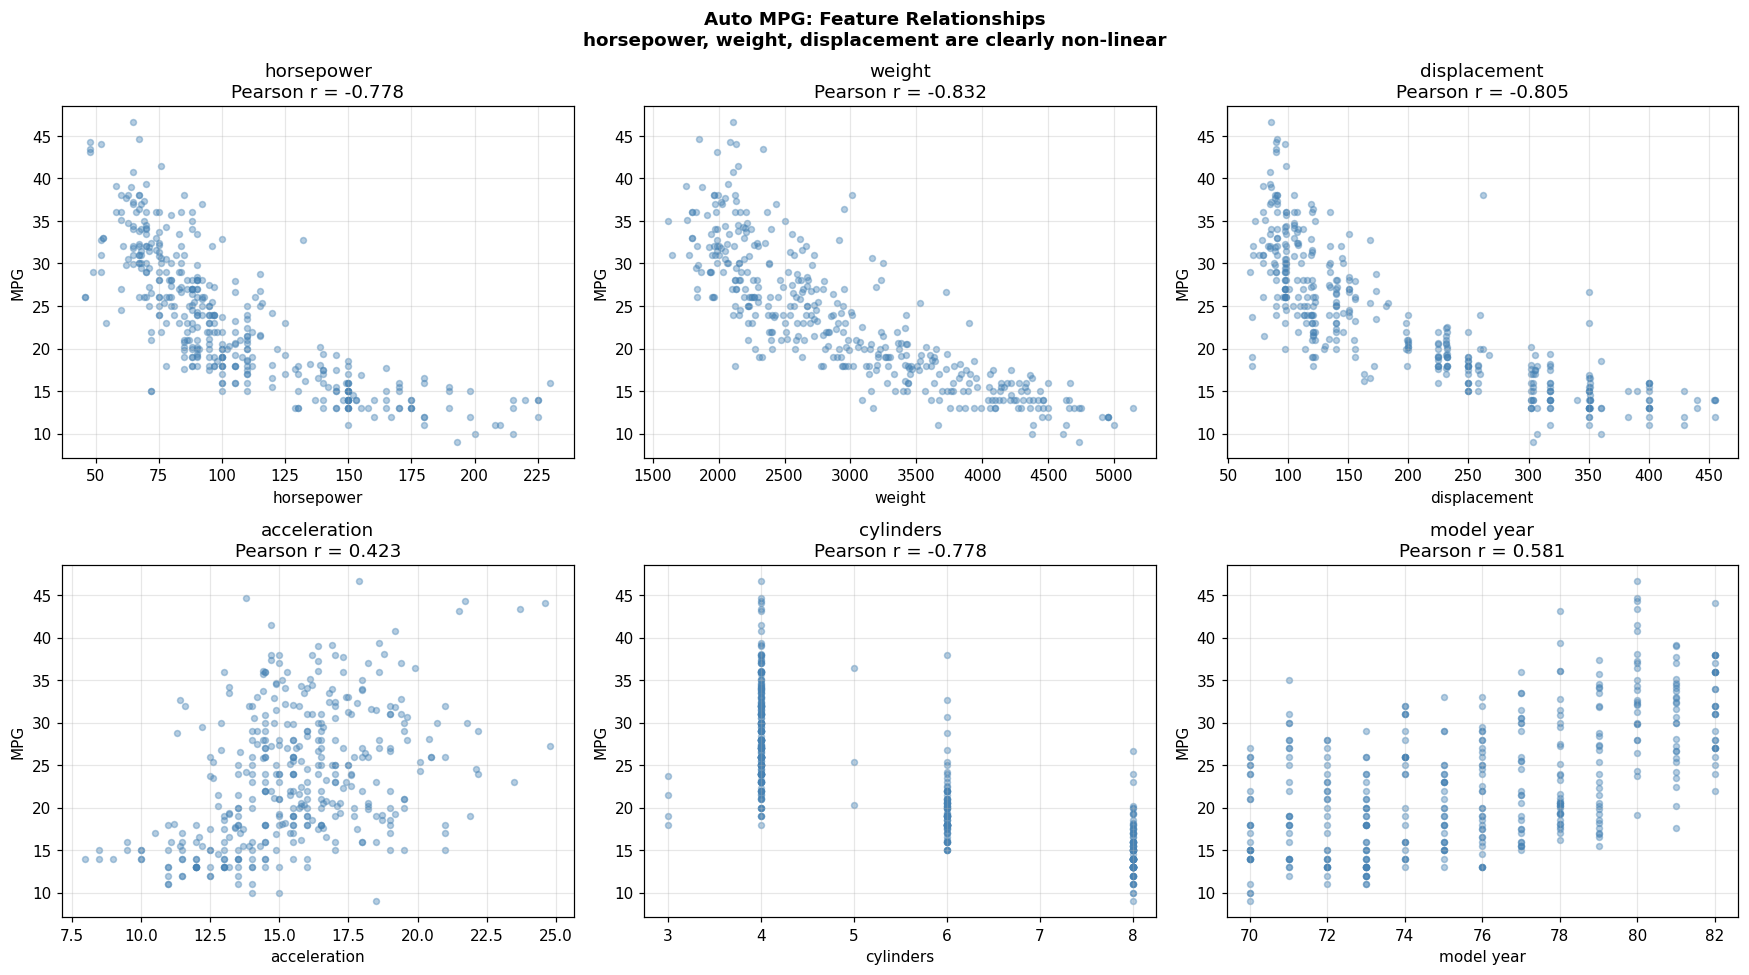

Key observations:
  • horsepower vs mpg: clear downward curve (not a straight line)
  • weight vs mpg:     strong negative relationship, slightly curved
  • model year vs mpg: positive trend — newer cars are more efficient
  • displacement:      similar curve to horsepower (they're correlated)


In [64]:
# ── EDA: understand the relationships ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

features_plot = ['horsepower', 'weight', 'displacement', 'acceleration', 'cylinders', 'model year']

for ax, feat in zip(axes.flat, features_plot):
    ax.scatter(df_clean[feat], df_clean['mpg'], alpha=0.4, s=15, color='steelblue')
    r = df_clean[[feat, 'mpg']].corr().iloc[0, 1]
    ax.set_xlabel(feat)
    ax.set_ylabel('MPG')
    ax.set_title(f'{feat}\nPearson r = {r:.3f}')

plt.suptitle('Auto MPG: Feature Relationships\n'
            'horsepower, weight, displacement are clearly non-linear',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  • horsepower vs mpg: clear downward curve (not a straight line)")
print("  • weight vs mpg:     strong negative relationship, slightly curved")
print("  • model year vs mpg: positive trend — newer cars are more efficient")
print("  • displacement:      similar curve to horsepower (they're correlated)")


  Horsepower → MPG: Linear vs Polynomial
    Degree    Train R²     Test R²    Test RMSE
  ------------------------------------------------
         1      0.6121      0.5674       4.6991 ← best
         2      0.6956      0.6406       4.2830 ← best
         3      0.6964      0.6395       4.2898
         4      0.6966      0.6411       4.2800 ← best


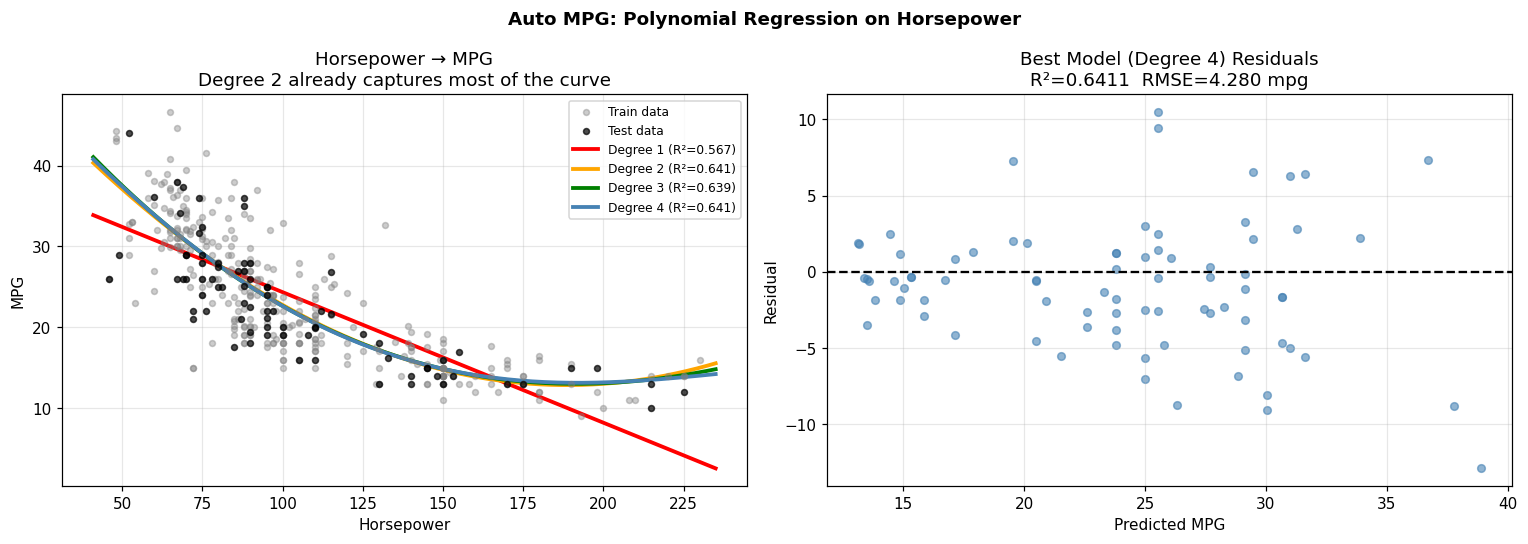

In [65]:
# ── Single feature: horsepower vs MPG ────────────────────────────────────────
# This is the textbook non-linear regression example

X_hp = df_clean[['horsepower']].values
y_mpg = df_clean['mpg'].values

X_hp_tr, X_hp_te, y_mpg_tr, y_mpg_te = train_test_split(
    X_hp, y_mpg, test_size=0.2, random_state=42)

hp_plot = np.linspace(df_clean['horsepower'].min() - 5,
                       df_clean['horsepower'].max() + 5, 300).reshape(-1, 1)

print("=" * 60)
print("  Horsepower → MPG: Linear vs Polynomial")
print("=" * 60)
print(f"  {'Degree':>8}  {'Train R²':>10}  {'Test R²':>10}  {'Test RMSE':>11}")
print("  " + "-" * 48)

hp_results = {}
for deg in [1, 2, 3, 4]:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge',  RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)),
    ])
    pipe.fit(X_hp_tr, y_mpg_tr)
    r2_tr  = r2_score(y_mpg_tr, pipe.predict(X_hp_tr))
    r2_te  = r2_score(y_mpg_te, pipe.predict(X_hp_te))
    rmse_  = np.sqrt(mean_squared_error(y_mpg_te, pipe.predict(X_hp_te)))
    hp_results[deg] = {'pipe': pipe, 'r2_tr': r2_tr, 'r2_te': r2_te, 'rmse': rmse_}
    flag = " ← best" if r2_te == max(r['r2_te'] for r in hp_results.values()) else ""
    print(f"  {deg:>8}  {r2_tr:>10.4f}  {r2_te:>10.4f}  {rmse_:>11.4f}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All degrees on one plot
colors_deg = {1: 'red', 2: 'orange', 3: 'green', 4: 'steelblue'}
axes[0].scatter(X_hp_tr, y_mpg_tr, s=15, alpha=0.4, color='gray', label='Train data', zorder=3)
axes[0].scatter(X_hp_te, y_mpg_te, s=15, alpha=0.7, color='black', label='Test data', zorder=4)
for deg in [1, 2, 3, 4]:
    pipe = hp_results[deg]['pipe']
    r2_te = hp_results[deg]['r2_te']
    axes[0].plot(hp_plot, pipe.predict(hp_plot), '-', lw=2.5,
                color=colors_deg[deg], label=f'Degree {deg} (R²={r2_te:.3f})')
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('MPG')
axes[0].set_title('Horsepower → MPG\nDegree 2 already captures most of the curve')
axes[0].legend(fontsize=8)

# Best model residuals
best_deg = max(hp_results, key=lambda d: hp_results[d]['r2_te'])
best_pipe = hp_results[best_deg]['pipe']
resids_best = y_mpg_te - best_pipe.predict(X_hp_te)

axes[1].scatter(best_pipe.predict(X_hp_te), resids_best,
                s=25, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='k', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted MPG')
axes[1].set_ylabel('Residual')
axes[1].set_title(f'Best Model (Degree {best_deg}) Residuals\n'
                  f'R²={hp_results[best_deg]["r2_te"]:.4f}  '
                  f'RMSE={hp_results[best_deg]["rmse"]:.3f} mpg')

plt.suptitle('Auto MPG: Polynomial Regression on Horsepower', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


  Multi-Feature: Linear vs Polynomial + Regularization
                           Model    Train R²     Test R²      RMSE
  ----------------------------------------------------------------
      Linear (no regularization)      0.8260      0.7902     3.273 ← best
                  Linear + Ridge      0.8257      0.7875     3.293
                Degree 2 + Ridge      0.8864      0.8536     2.734 ← best
                Degree 3 + Ridge      0.9106      0.8706     2.570 ← best


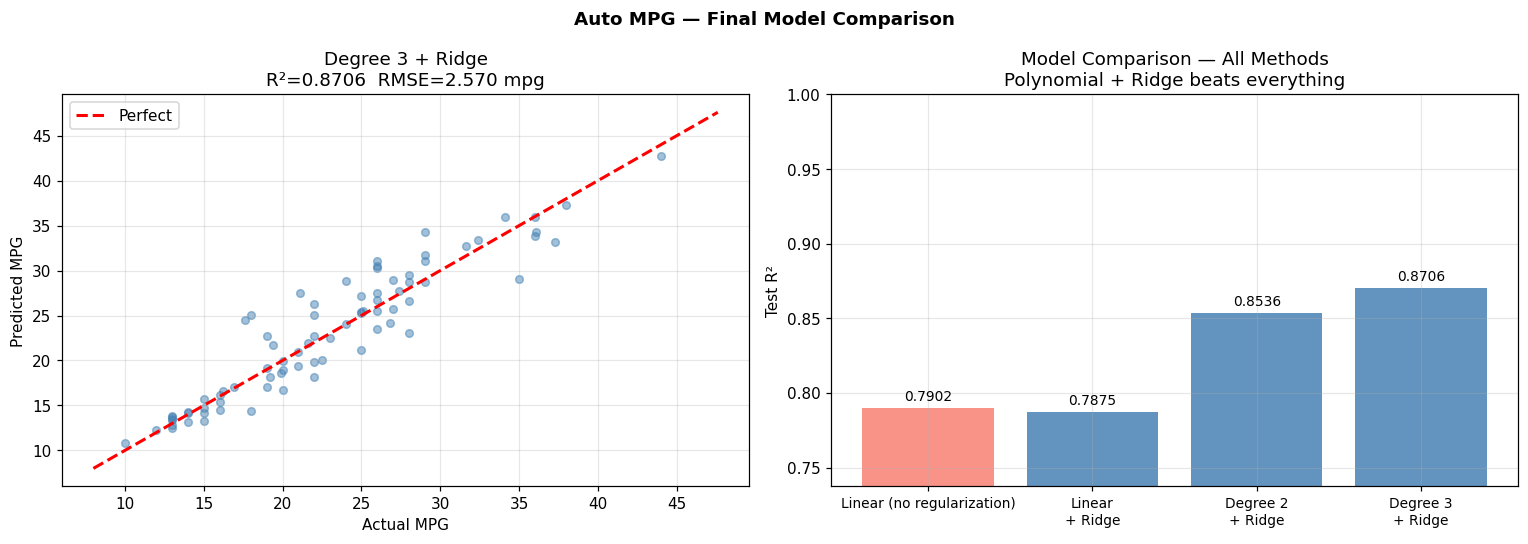


Best model: Degree 3 + Ridge
  R² = 0.8706 — the model explains 87.1% of MPG variance
  RMSE = 2.570 mpg — average prediction error


In [66]:
# ── Multi-feature polynomial regression ───────────────────────────────────────
# Now use all features together

feature_cols = ['horsepower', 'weight', 'displacement', 'acceleration',
                'cylinders', 'model year', 'origin']

X_all = df_clean[feature_cols].values
y_all = df_clean['mpg'].to_numpy(dtype=float)

X_all_tr, X_all_te, y_all_tr, y_all_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

print("=" * 65)
print("  Multi-Feature: Linear vs Polynomial + Regularization")
print("=" * 65)
print(f"  {'Model':>30}  {'Train R²':>10}  {'Test R²':>10}  {'RMSE':>8}")
print("  " + "-" * 64)

all_results = {}
model_configs = [
    ('Linear (no regularization)',      1, False),
    ('Linear + Ridge',                  1, True),
    ('Degree 2 + Ridge',                2, True),
    ('Degree 3 + Ridge',                3, True),
]

for name, deg, use_ridge in model_configs:
    final_model = RidgeCV(alphas=np.logspace(-3, 4, 40), cv=5) if use_ridge else LinearRegression()
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  final_model),
    ])
    pipe.fit(X_all_tr, y_all_tr)
    r2_tr = r2_score(y_all_tr, pipe.predict(X_all_tr))
    r2_te = r2_score(y_all_te, pipe.predict(X_all_te))
    rmse_ = np.sqrt(mean_squared_error(y_all_te, pipe.predict(X_all_te)))
    all_results[name] = {'pipe': pipe, 'r2_tr': r2_tr, 'r2_te': r2_te, 'rmse': rmse_}
    flag = " ← best" if r2_te == max(r['r2_te'] for r in all_results.values()) else ""
    print(f"  {name:>30}  {r2_tr:>10.4f}  {r2_te:>10.4f}  {rmse_:>8.3f}{flag}")

# ── Final visualization ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted — best model
best_model_name = max(all_results, key=lambda k: all_results[k]['r2_te'])
best_res        = all_results[best_model_name]
y_pred_best     = best_res['pipe'].predict(X_all_te)

axes[0].scatter(y_all_te, y_pred_best, alpha=0.5, s=25, color='steelblue')
lim = [y_all.min() - 1, y_all.max() + 1]
axes[0].plot(lim, lim, 'r--', lw=2, label='Perfect')
axes[0].set_xlabel('Actual MPG')
axes[0].set_ylabel('Predicted MPG')
axes[0].set_title(f'{best_model_name}\nR²={best_res["r2_te"]:.4f}  RMSE={best_res["rmse"]:.3f} mpg')
axes[0].legend()

# Model comparison bars
names  = list(all_results.keys())
r2_tes = [all_results[n]['r2_te'] for n in names]
colors_cmp = ['salmon' if 'no reg' in n else 'steelblue' for n in names]
bars = axes[1].bar(range(len(names)), r2_tes, color=colors_cmp, alpha=0.85)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels([n.replace(' + ', '\n+ ') for n in names], fontsize=9)
axes[1].set_ylabel('Test R²')
axes[1].set_title('Model Comparison — All Methods\n'
                  'Polynomial + Ridge beats everything')
axes[1].set_ylim(min(r2_tes) - 0.05, 1.0)
for bar, val in zip(bars, r2_tes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Auto MPG — Final Model Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest model: {best_model_name}")
print(f"  R² = {best_res['r2_te']:.4f} — the model explains {best_res['r2_te']*100:.1f}% of MPG variance")
print(f"  RMSE = {best_res['rmse']:.3f} mpg — average prediction error")


---
## Summary — What to Remember as an ML Engineer

### The Core Idea
Polynomial regression = take our features, add `x²`, `x³`, etc., then run linear regression.
We're not changing the algorithm — We're enriching the features.

### The Standard Workflow

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV
import numpy as np

pipe = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),  # add x²
    ('scaler', StandardScaler()),                                   # scale features
    ('ridge',  RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),      # regularize
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
```

### Degree Choice

| Degree | Use when |
|---|---|
| 1 | Try this first always |
| 2 | Residual plot shows a curve — most real problems |
| 3 | Degree 2 still shows a pattern in residuals |
| 4+ | Rare — almost always use Ridge too |

### Key Rules

1. **Always use StandardScaler** before polynomial features
2. **Always use regularization** (Ridge or Lasso) with polynomial features
3. **Use cross-validation** to choose degree — don't just try on test set
4. **Watch the feature count** — degree=3 with 10 features = 286 columns
5. **Start simple** — degree=2 solves most real-world non-linearities

### When Polynomial Regression Isn't the Answer
- Too many features → feature explosion → use tree-based models instead
- Very complex non-linearity → neural networks handle this better
- We just want to try many things fast → XGBoost/LightGBM

### What's Next
- `decision_trees.ipynb` — non-linear regression without polynomial features
- `regression_kaggle.ipynb` — full pipeline on House Prices competition
